# Embedding Visualization: t-SNE + KMeans Clustering

This notebook:
1. Loads a pretrained encoder checkpoint
2. Extracts embeddings from a dataset split
3. Visualizes with **t-SNE** (coloured by subject, label, KMeans cluster)
4. Runs **KMeans** clustering and evaluates with ARI, NMI, Silhouette
5. Shows a **heatmap** of KMeans clusters vs subject IDs

## 0. Install dependencies (if needed)

# Plot some samplé

## 1. Imports

In [2]:
import os
import umap
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# ── Add repo root to path (edit if running from a different directory) ──
REPO_ROOT = "."   # change to absolute path if needed, e.g. "/home/user/SSL-invariance-Subject_Project_model/Subject-aware_SSL"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from models.net.CNNEncoder import CNNEncoder
from models.net.convnextv1 import convnext_stiny
from datasets.wesad_dataset import WESADDataset
from datasets.swell_dataset import SWELLDataset
from datasets.psy_dataset import PsyDataset
from sklearn.preprocessing import normalize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'models'

In [ ]:
#Get the dataset from the config file
def get_dataset(config):
    dataset_name = config["dataset"]["name"].lower()
    if dataset_name == "wesad":
        return WESADDataset(config)
    elif dataset_name == "swell":
        return SWELLDataset(config)
    elif dataset_name == "psy":
        return PsyDataset(config)
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

## 2. Configuration — Edit these paths

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# You can define MULTIPLE runs to compare side-by-side.
# Each entry is a dict with the keys shown below.
# ─────────────────────────────────────────────────────────────────────────────

RUNS = [
    {
        "label":        "Subject-Specific",
        "checkpoint":   "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/subject_specific_SWELLDataset/encoder_best_.pt",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/SWELL/SWELL_1280_320",
        "data_name":    "SWELLDataset",   # "WESADDataset" | "SWELLDataset" | "PsychioNet"
    },
    {
            "label":        "Subject-Contrastive",
            "checkpoint":   "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/contrastive_SWELLDataset/encoder_best_.pt",
            "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/SWELL/SWELL_1280_320",
            "data_name":    "SWELLDataset",   # "WESADDataset" | "SWELLDataset" | "PsychioNet"
        },
    {
        "label":        "Subject-Invariant",
        "checkpoint":   "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/subject_invariant_SWELLDataset/encoder_best_.pt",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/SWELL/SWELL_1280_320",
        "data_name":    "SWELLDataset",   # "WESADDataset" | "SWELLDataset" | "PsychioNet"
    },
]

# ── Encoder architecture ─────────────────────────────────────────────────────
ENCODER_NAME  = "cnn"    # "cnn" | "convnextv1"
INPUT_DIM     = 1280     # signal length fed to CNN
OUTPUT_DIM    = 64       # encoder output dim

# ── t-SNE hyperparameters ─────────────────────────────────────────────────────
PERPLEXITY    = 30
N_ITER        = 1000
TSNE_SEED     = 42

# ── KMeans ───────────────────────────────────────────────────────────────────
N_CLUSTERS    = 10     # None → auto-set to number of unique subjects
KMEANS_SEED   = 42

# ── DataLoader ───────────────────────────────────────────────────────────────
BATCH_SIZE    = 256
NUM_WORKERS   = 4

# ── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR    = "./embedding_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config OK ✓")

Config OK ✓


## 3. Helper Functions

In [ ]:
# ── Encoder builder ───────────────────────────────────────────────────────────
def build_encoder(name, input_dim, output_dim):
    if name == "cnn":
        return CNNEncoder(input_dim=input_dim, kernel_size=10, stride=1,
                          dropout_prob=0.0, output_dim=output_dim)
    elif name == "convnextv1":
        return convnext_stiny(output_dim=output_dim)
    raise ValueError(f"Unknown encoder: {name}")


# ── Checkpoint loader ─────────────────────────────────────────────────────────
def load_encoder(checkpoint_path, encoder, device):
    ckpt       = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state_dict = ckpt.get("state_dict", ckpt)

    new_state = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k[len("module."):]
        for prefix in ("encoder_q.", "encoder_i.", "encoder."):
            if k.startswith(prefix):
                new_state[k[len(prefix):]] = v
                break
        else:
            new_state[k] = v

    msg = encoder.load_state_dict(new_state, strict=False)
    if msg.missing_keys:
        print(f"  [WARN] Missing keys: {msg.missing_keys}")
    encoder.to(device).eval()
    print(f"  Loaded: {checkpoint_path}")
    return encoder


# ── Dataset loader ────────────────────────────────────────────────────────────
def build_dataset(data_name, dataset_path, split, split_file):
    common = dict(
        dataset_path=dataset_path, include_labels=True,
        split=split, split_file=split_file, sub_sample_frac=None,
        data_views=None, transform_dict_core=None,
        transform_dict_artifact=None, transform_global_core=None,
        transform_global_artifact=None,
    )
    if data_name == "WESADDataset":  return WESADDataset(**common)
    if data_name == "SWELLDataset":  return SWELLDataset(**common)
    if data_name == "PsychioNet":    return PsyDataset(**common)
    raise ValueError(f"Unknown dataset: {data_name}")
    

# ── Embedding extractor ───────────────────────────────────────────────────────
@torch.no_grad()
def extract_embeddings(encoder, loader, device, l2_normalize=False):
    embeds, subjects, labels = [], [], []
    for batch in loader:
        x = batch["x"].to(device, non_blocking=True).float()
        if x.dim() == 2:
            x = x.unsqueeze(1)
        h = encoder(x)
        embeds.append(h.cpu().numpy())
        subjects.append(batch["subject_id_int"].numpy())
        if "y" in batch:
            labels.append(batch["y"].numpy())
    E = np.concatenate(embeds, axis=0)
    S = np.concatenate(subjects, axis=0)
    L = np.concatenate(labels, axis=0).ravel() if labels else None
    
    if l2_normalize:
        E = normalize(E, norm="l2")   # ← maps all embeddings onto unit hypersphere
    return E, S, L

# ── Clustering metrics ────────────────────────────────────────────────────────
def clustering_metrics(true_labels, pred_labels, embeddings):
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    sil = silhouette_score(embeddings, pred_labels,
                           sample_size=min(5000, len(embeddings)))
    return {"ARI": round(ari, 4), "NMI": round(nmi, 4),
            "Silhouette": round(sil, 4)}

print("Helpers defined ✓")

Helpers defined ✓


## 4. Extract Embeddings for Each Run

In [ ]:
run_data = []   # will hold results for each run

for cfg in RUNS:
    print(f"\n{'='*60}")
    print(f"Run: {cfg['label']}")
    print(f"{'='*60}")
    data_args = cfg["data_name"], cfg["dataset_path"], cfg.get("split", None), cfg.get("split_file", None)
    # Build encoder + load weights
    encoder = build_encoder(ENCODER_NAME, INPUT_DIM, OUTPUT_DIM)
    encoder = load_encoder(cfg["checkpoint"], encoder, device)

    # Build dataset + dataloader
    dataset = build_dataset(*data_args)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
    print(f"  Samples: {len(dataset)}, "
          f"Subjects: {dataset.num_subjects}")

    # Extract
    E, S, L = extract_embeddings(encoder, loader, device)
    print(f"  Embeddings: {E.shape}")

    # t-SNE
    print(f"  Running t-SNE (perplexity={PERPLEXITY}) …")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    XY = reducer.fit_transform(E)

    # KMeans
    k = N_CLUSTERS or len(np.unique(S))
    print(f"  Running KMeans (k={k}) …")
    km = KMeans(n_clusters=k, random_state=KMEANS_SEED, n_init=10)
    K  = km.fit_predict(E)

    # Metrics
    metrics = clustering_metrics(S, K, E)
    print(f"  ARI={metrics['ARI']}  NMI={metrics['NMI']}  "
          f"Silhouette={metrics['Silhouette']}")

    run_data.append({
        "label":   cfg["label"],
        "E": E, "XY": XY, "S": S, "L": L, "K": K,
        "k": k, "metrics": metrics,
    })

print("\nAll runs complete ✓")


Run: Subject-Specific
  Loaded: /home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/subject_specific_SWELLDataset/encoder_best_.pt
reading data for subject s10
reading data for subject s11
reading data for subject s12
reading data for subject s13
reading data for subject s14
reading data for subject s15
reading data for subject s16
reading data for subject s17
reading data for subject s18
reading data for subject s19
reading data for subject s1
reading data for subject s20
reading data for subject s21
reading data for subject s22
reading data for subject s23
reading data for subject s24
reading data for subject s25
reading data for subject s2
reading data for subject s3
reading data for subject s4
reading data for subject s5
reading data for subject s6
reading data for subject s7
reading data for subject s8
reading data for subject s9
sub sample frac is None
Label 0 count: 92465 = 100.0%
  Samples: 92465, Subjects: 25
  Embeddings:

/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  Running KMeans (k=25) …
  ARI=0.9048  NMI=0.9354  Silhouette=0.6355

Run: Subject-Contrastive
  Loaded: /home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/contrastive_SWELLDataset/encoder_best_.pt
reading data for subject s10
reading data for subject s11
reading data for subject s12
reading data for subject s13
reading data for subject s14
reading data for subject s15
reading data for subject s16
reading data for subject s17
reading data for subject s18
reading data for subject s19
reading data for subject s1
reading data for subject s20
reading data for subject s21
reading data for subject s22
reading data for subject s23
reading data for subject s24
reading data for subject s25
reading data for subject s2
reading data for subject s3
reading data for subject s4
reading data for subject s5
reading data for subject s6
reading data for subject s7
reading data for subject s8
reading data for subject s9
sub sample frac is None
Label 

/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  Running KMeans (k=25) …
  ARI=0.6747  NMI=0.7983  Silhouette=0.2063

Run: Subject-Invariant
  Loaded: /home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/cnn_overlap/subject_invariant_SWELLDataset/encoder_best_.pt
reading data for subject s10
reading data for subject s11
reading data for subject s12
reading data for subject s13
reading data for subject s14
reading data for subject s15
reading data for subject s16
reading data for subject s17
reading data for subject s18
reading data for subject s19
reading data for subject s1
reading data for subject s20
reading data for subject s21
reading data for subject s22
reading data for subject s23
reading data for subject s24
reading data for subject s25
reading data for subject s2
reading data for subject s3
reading data for subject s4
reading data for subject s5
reading data for subject s6
reading data for subject s7
reading data for subject s8
reading data for subject s9
sub sample frac is None
La

/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/s223149341/miniconda3/envs/ssl_torch/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  Running KMeans (k=25) …
  ARI=0.8188  NMI=0.8878  Silhouette=0.2313

All runs complete ✓


## 5. t-SNE Overview (Subject / KMeans / Label)

/tmp/ipykernel_3252715/2664754051.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap(cmap_name, len(unique))


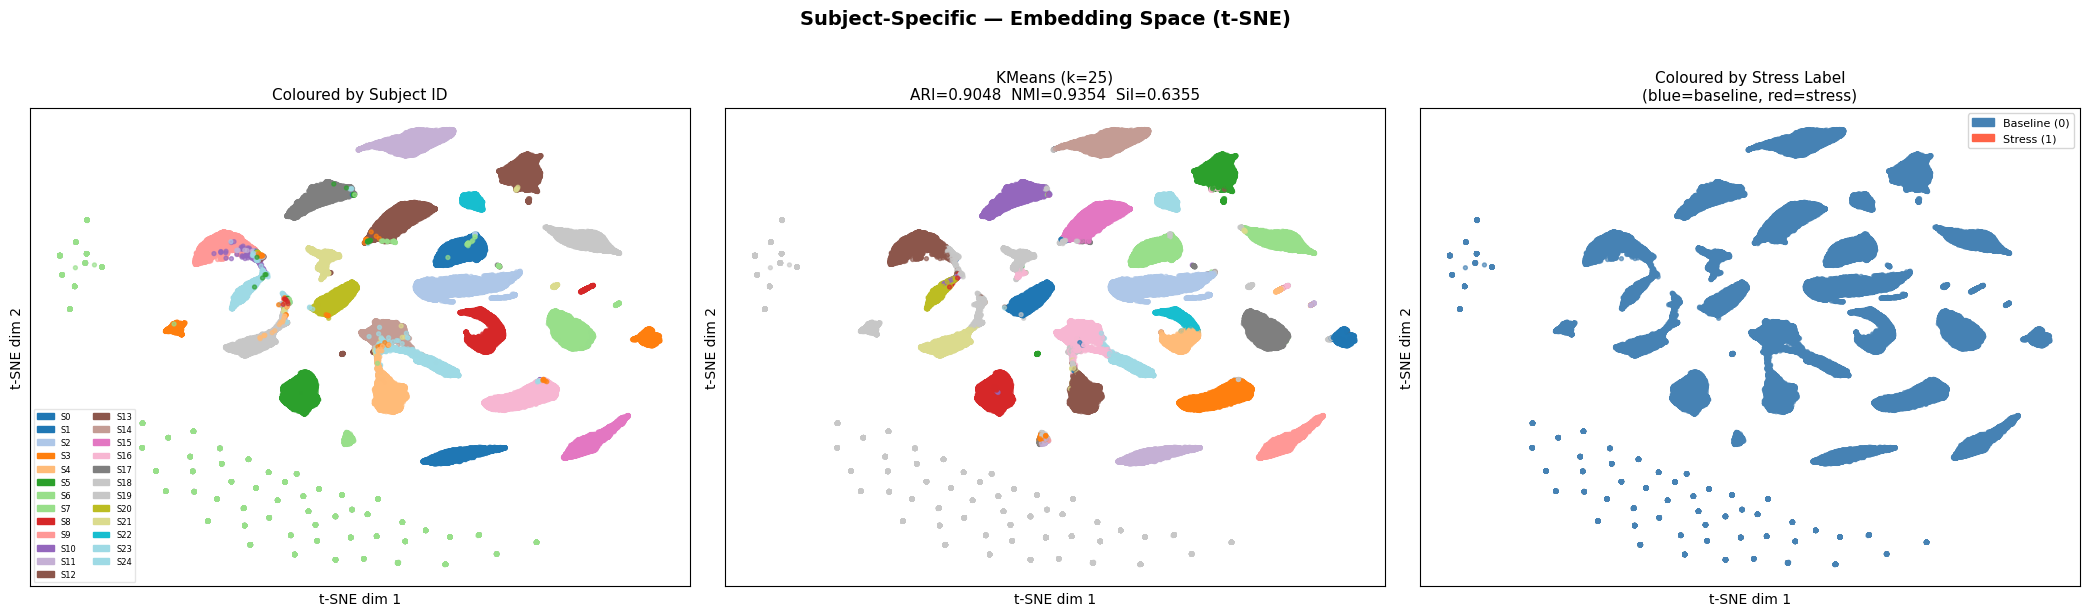

Saved → ./embedding_plots/Subject-Specific_tsne_overview.png


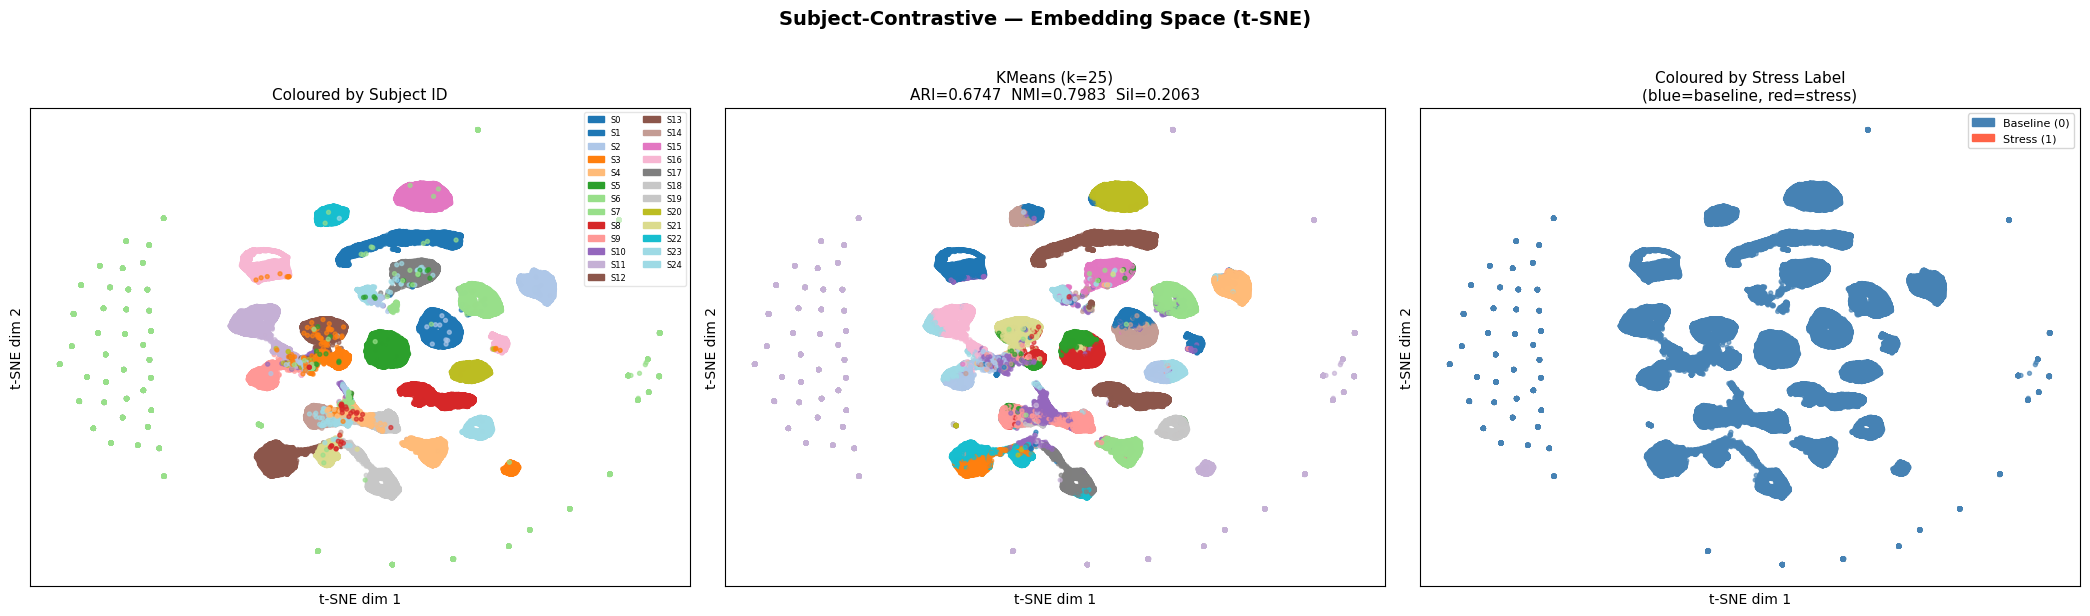

Saved → ./embedding_plots/Subject-Contrastive_tsne_overview.png


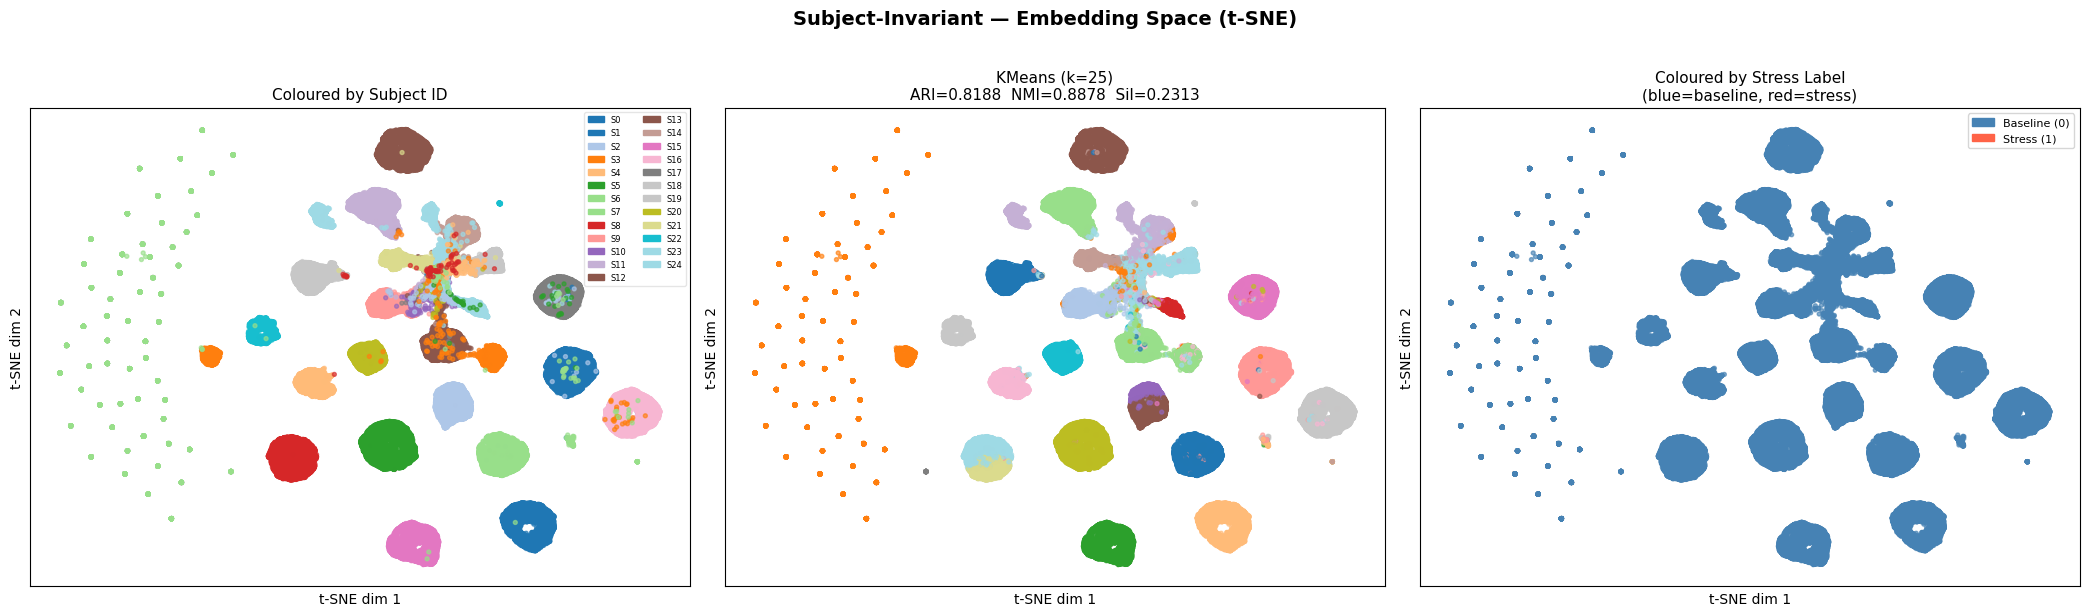

Saved → ./embedding_plots/Subject-Invariant_tsne_overview.png


In [5]:
def cmap_colors(ids, cmap_name="tab20"):
    unique = np.unique(ids)
    cmap   = cm.get_cmap(cmap_name, len(unique))
    id_to_color = {uid: cmap(i) for i, uid in enumerate(unique)}
    return np.array([id_to_color[i] for i in ids]), unique, cmap


for rd in run_data:
    XY, S, L, K = rd["XY"], rd["S"], rd["L"], rd["K"]
    m  = rd["metrics"]
    lbl = rd["label"]

    has_labels = L is not None
    ncols = 3 if has_labels else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    fig.suptitle(f"{lbl} — Embedding Space (t-SNE)",
                 fontsize=14, fontweight="bold", y=1.02)

    # ── Panel 1: Subject ID ────────────────────────────────────
    ax = axes[0]
    colors, unique_s, cmap_s = cmap_colors(S, "tab20")
    ax.scatter(XY[:, 0], XY[:, 1], c=colors, s=8, alpha=0.65)
    patches = [mpatches.Patch(color=cmap_s(i), label=f"S{uid}")
               for i, uid in enumerate(unique_s)]
    ax.legend(handles=patches, fontsize=6, ncol=2,
              loc="best", framealpha=0.5, markerscale=1.5)
    ax.set_title("Coloured by Subject ID", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")

    # ── Panel 2: KMeans ───────────────────────────────────────
    ax = axes[1]
    colors_k, _, _ = cmap_colors(K, "tab20")
    ax.scatter(XY[:, 0], XY[:, 1], c=colors_k, s=8, alpha=0.65)
    ax.set_title(
        f"KMeans (k={rd['k']})\n"
        f"ARI={m['ARI']}  NMI={m['NMI']}  Sil={m['Silhouette']}",
        fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")

    # ── Panel 3: Stress label (optional) ─────────────────────
    if has_labels:
        ax = axes[2]
        label_colors = np.where(L == 1, "tomato", "steelblue")
        ax.scatter(XY[:, 0], XY[:, 1], c=label_colors, s=8, alpha=0.65)
        ax.set_title("Coloured by Stress Label\n"
                     "(blue=baseline, red=stress)", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
        patches_l = [
            mpatches.Patch(color="steelblue", label="Baseline (0)"),
            mpatches.Patch(color="tomato",    label="Stress (1)"),
        ]
        ax.legend(handles=patches_l, fontsize=8, loc="best")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
                             f"{lbl.replace(' ', '_')}_tsne_overview.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

## 6. Per-Subject Highlight Plots

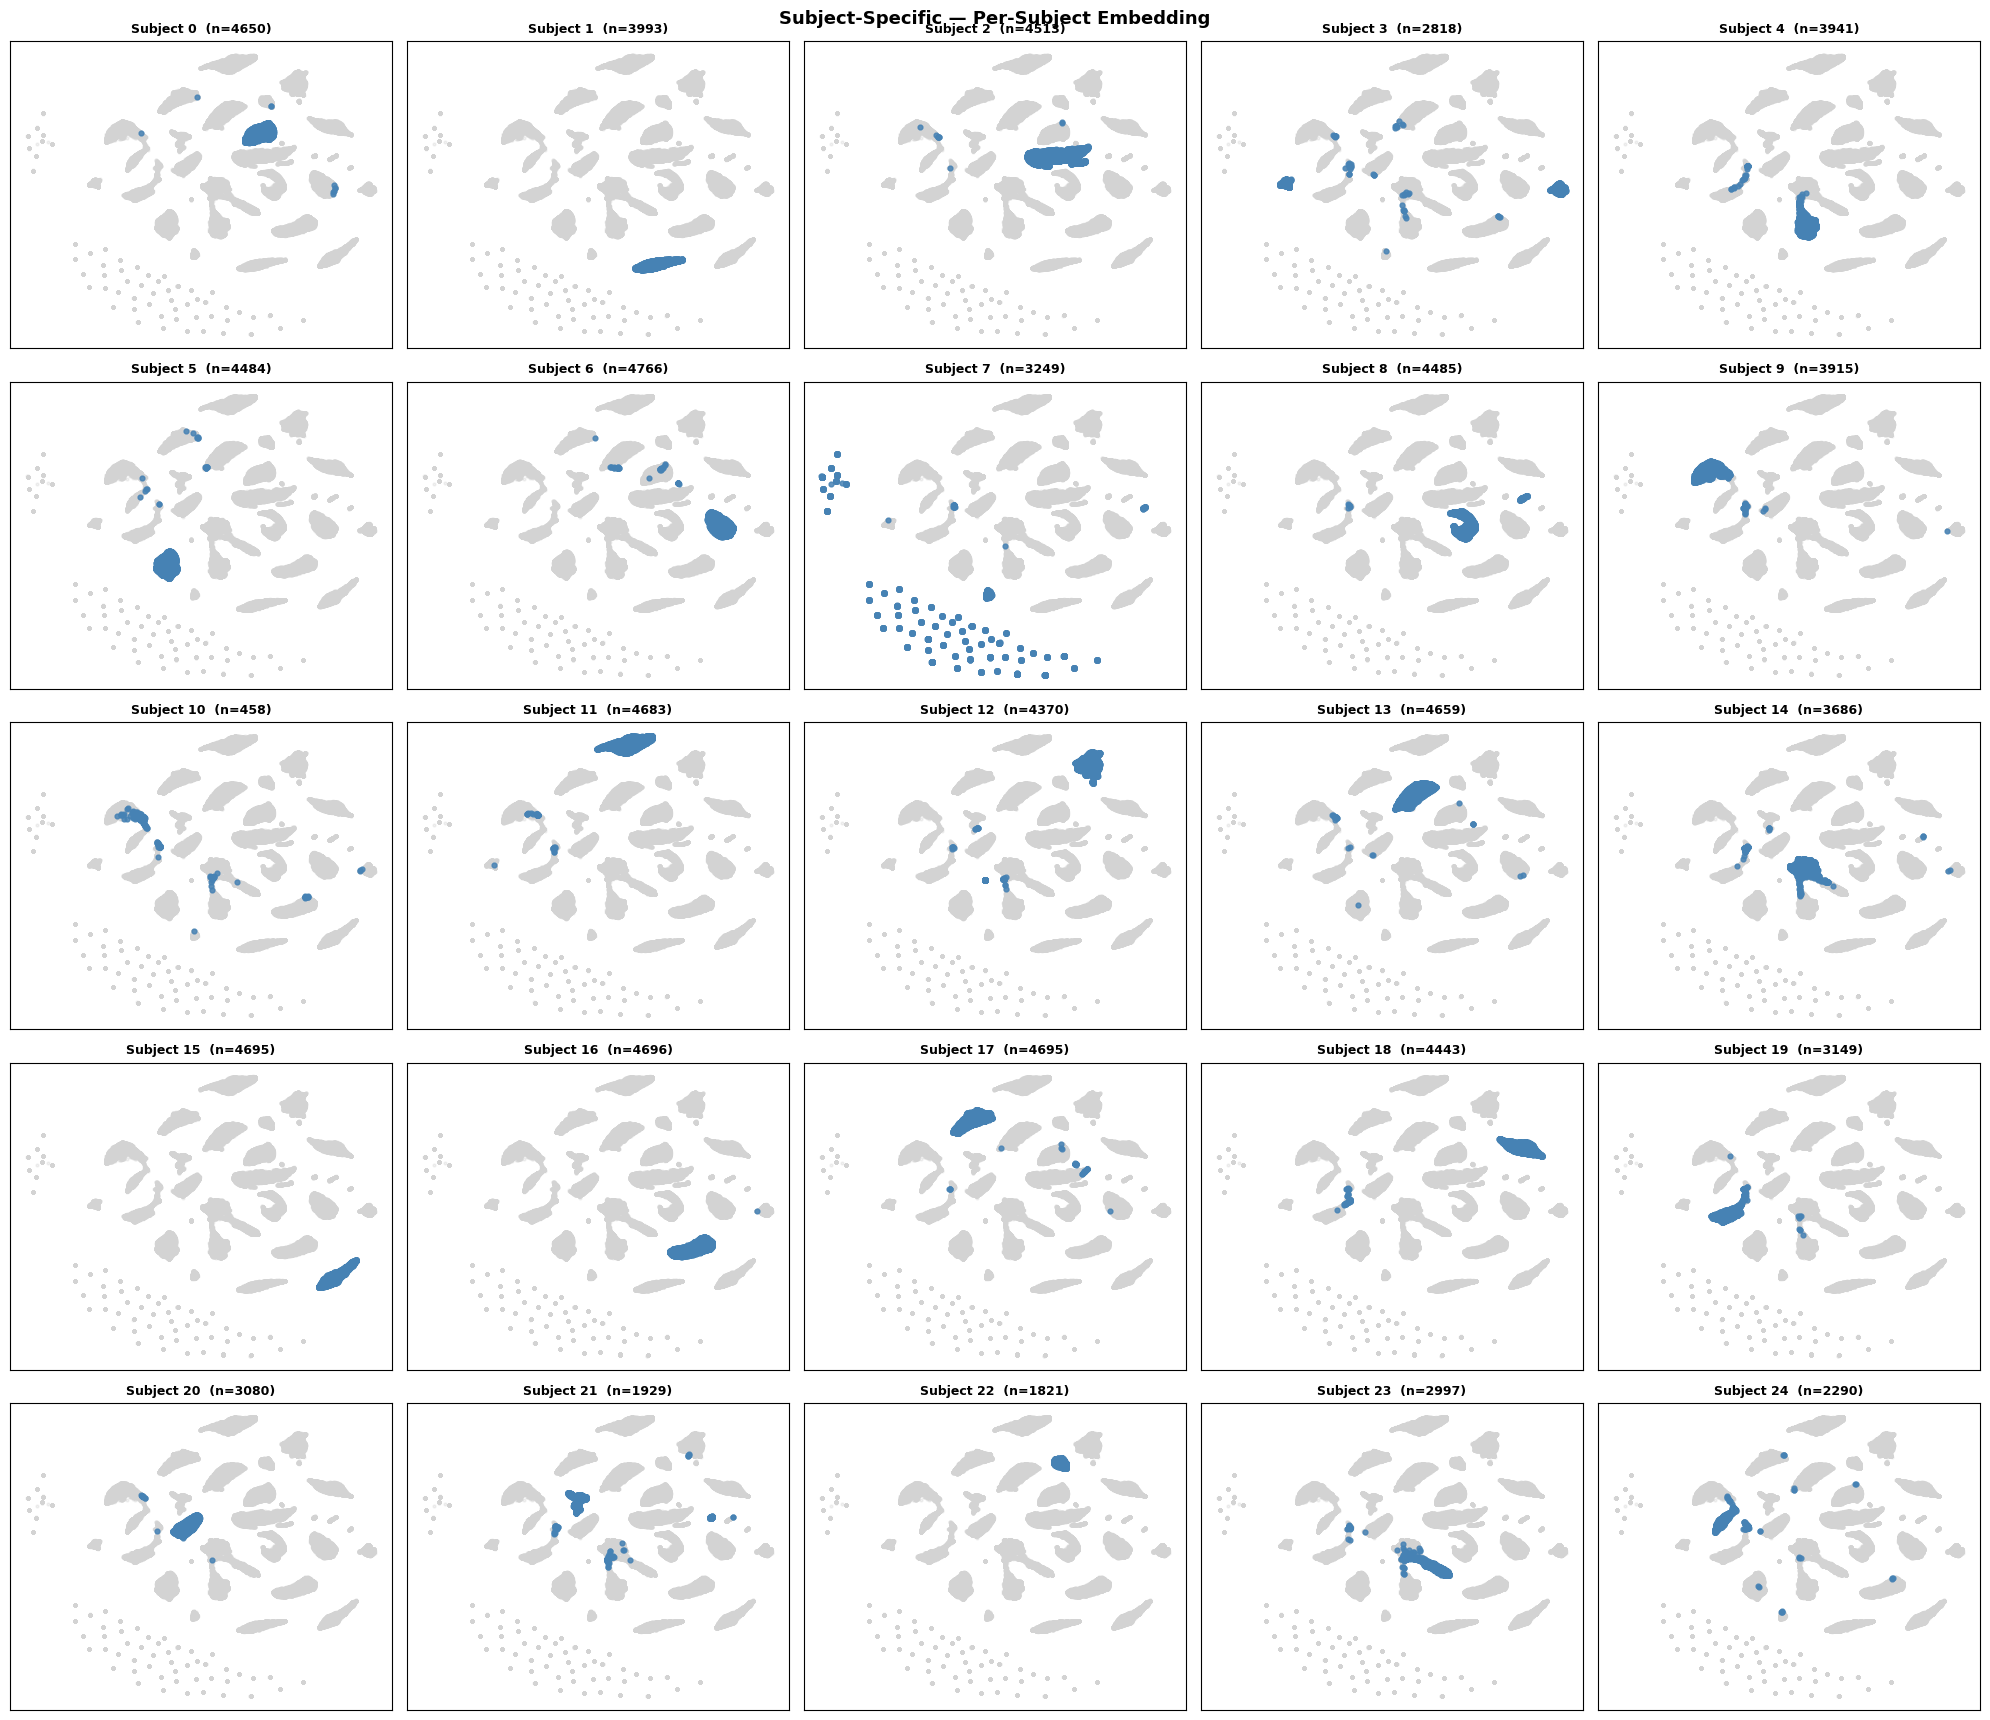

Saved → ./embedding_plots/Subject-Specific_per_subject.png


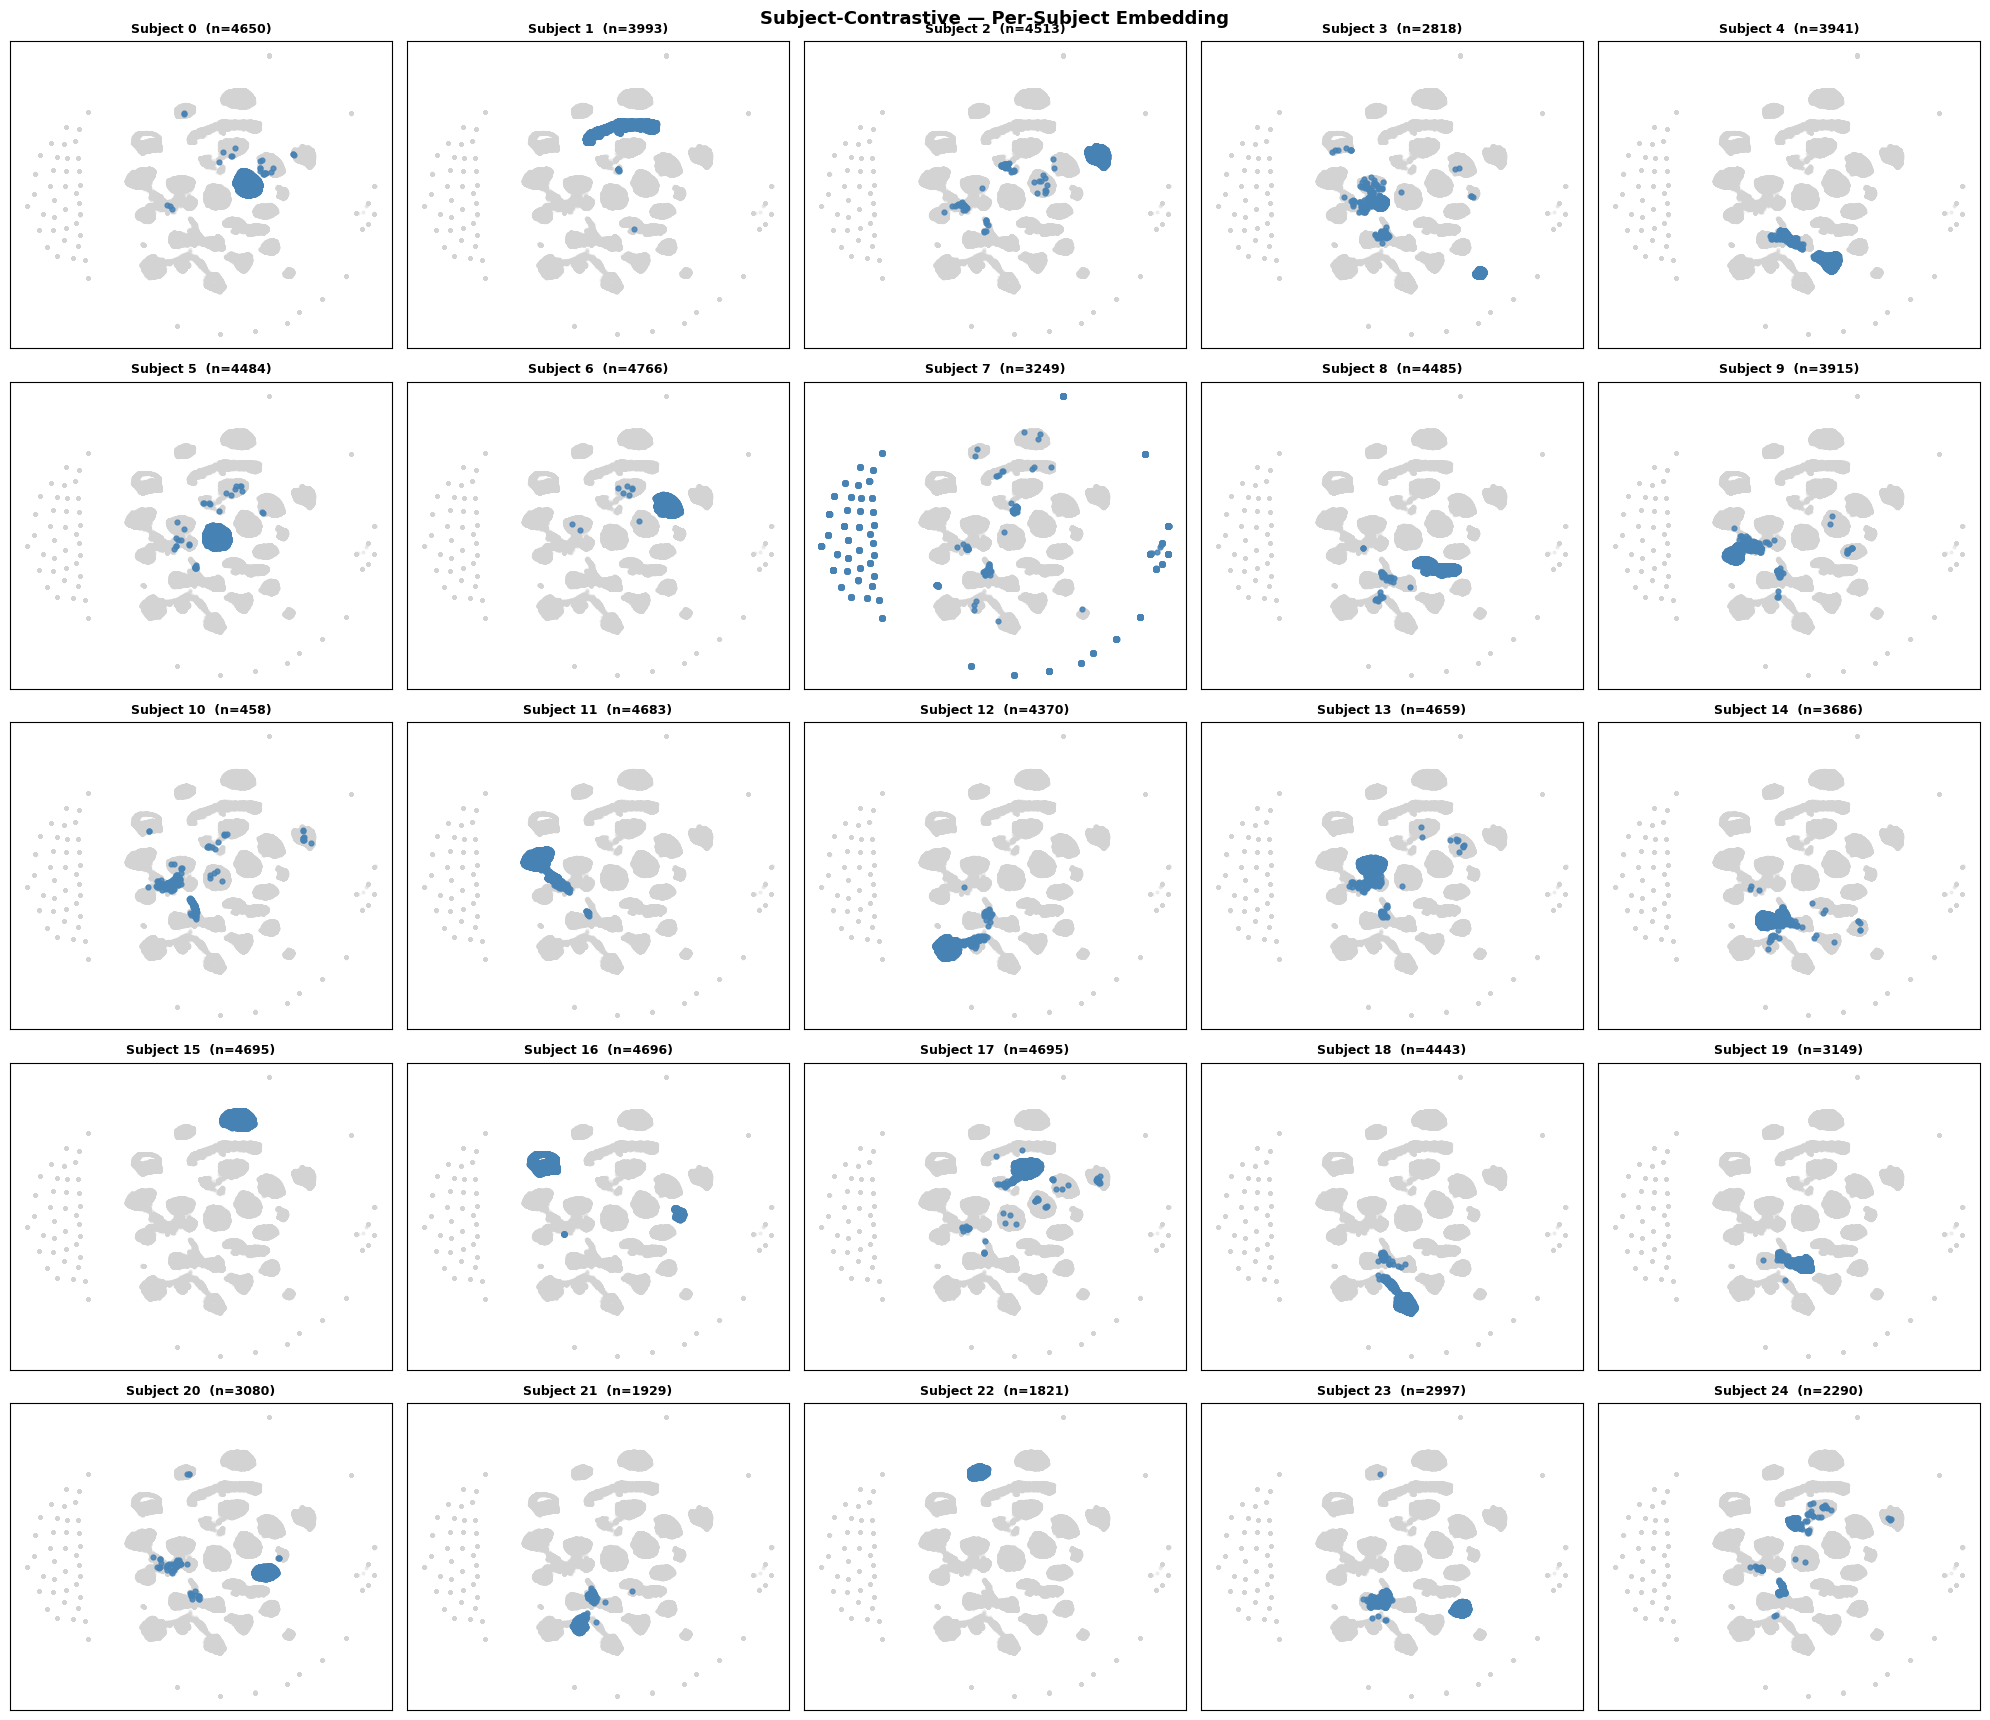

Saved → ./embedding_plots/Subject-Contrastive_per_subject.png


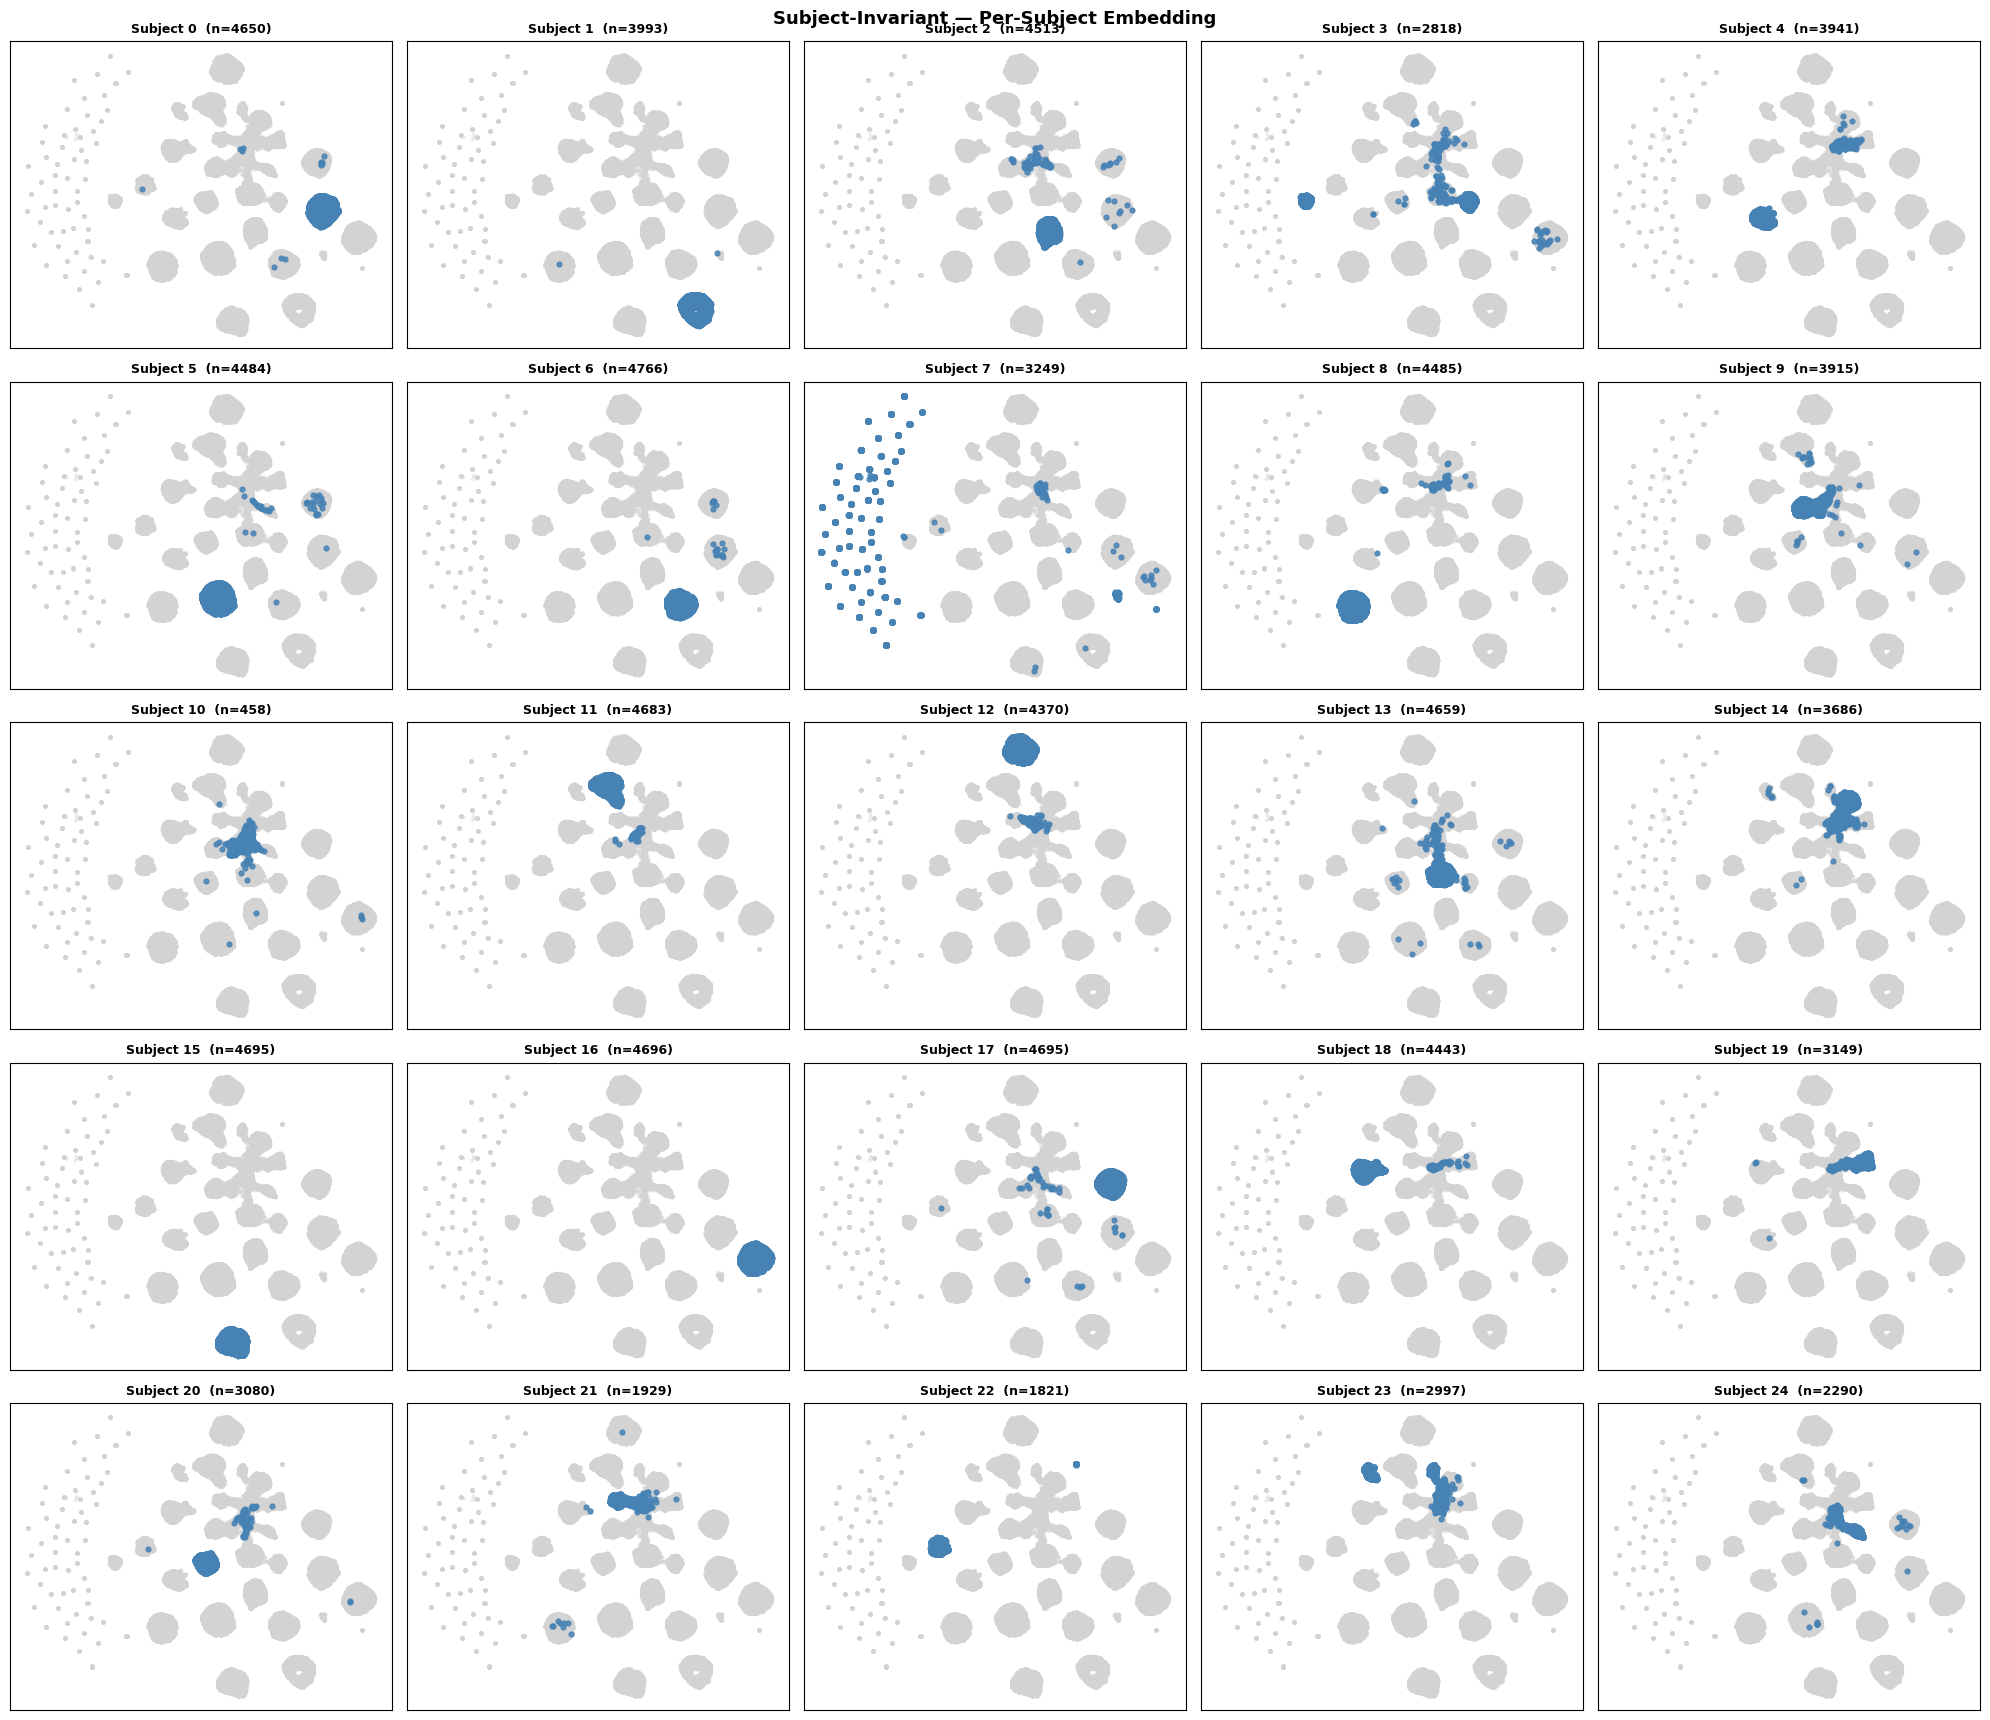

Saved → ./embedding_plots/Subject-Invariant_per_subject.png


In [6]:
for rd in run_data:
    XY, S = rd["XY"], rd["S"]
    unique_subjects = np.unique(S)
    ncols = min(5, len(unique_subjects))
    nrows = (len(unique_subjects) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).ravel()

    fig.suptitle(f"{rd['label']} — Per-Subject Embedding",
                 fontsize=13, fontweight="bold")

    for i, sid in enumerate(unique_subjects):
        ax   = axes[i]
        mask = S == sid
        ax.scatter(XY[~mask, 0], XY[~mask, 1],
                   c="lightgrey", s=4, alpha=0.3, rasterized=True)
        ax.scatter(XY[mask, 0],  XY[mask, 1],
                   c="steelblue", s=12, alpha=0.85,
                   label=f"Subject {sid}")
        ax.set_title(f"Subject {sid}  (n={mask.sum()})",
                     fontsize=9, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
                             f"{rd['label'].replace(' ', '_')}_per_subject.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

## 7. KMeans × Subject Heatmap

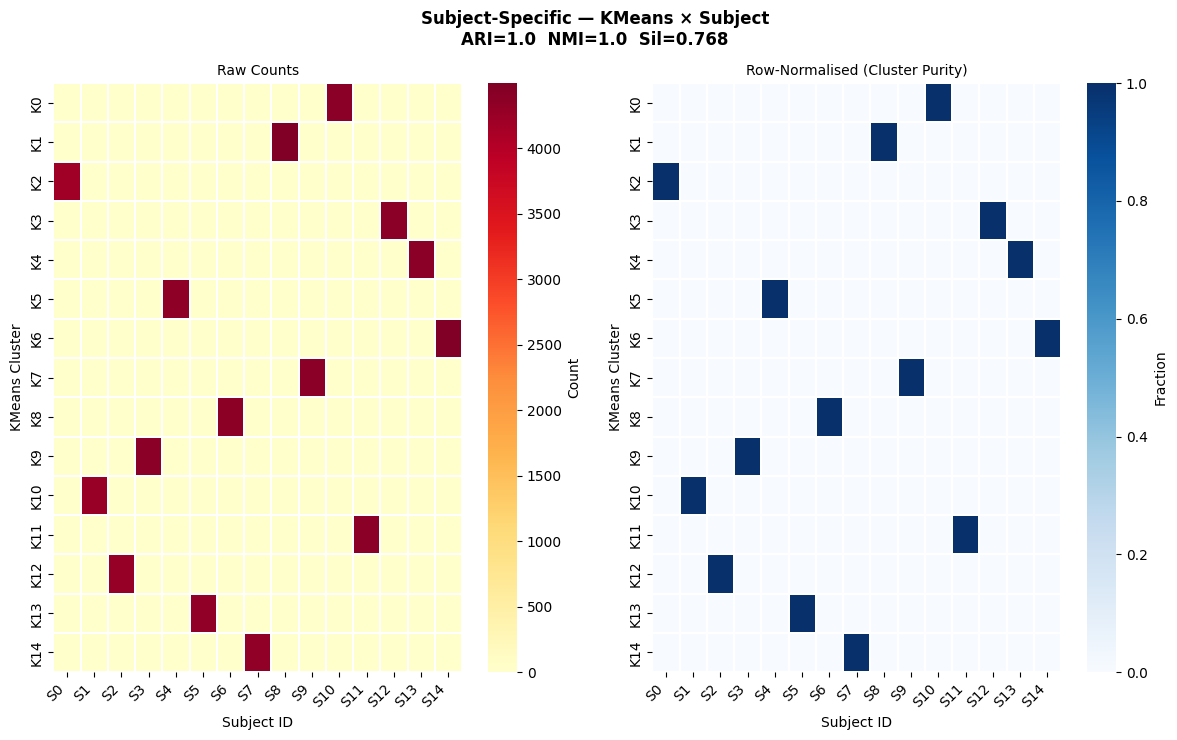

Saved → ./embedding_plots/Subject-Specific_heatmap.png


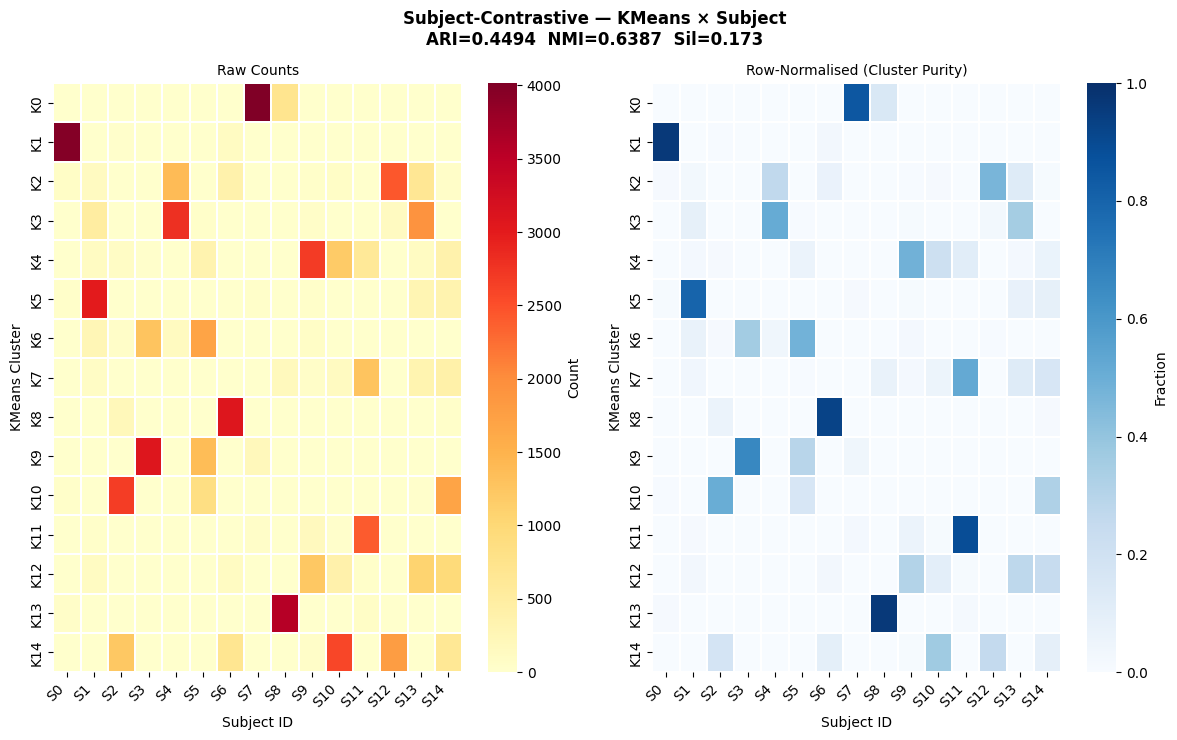

Saved → ./embedding_plots/Subject-Contrastive_heatmap.png


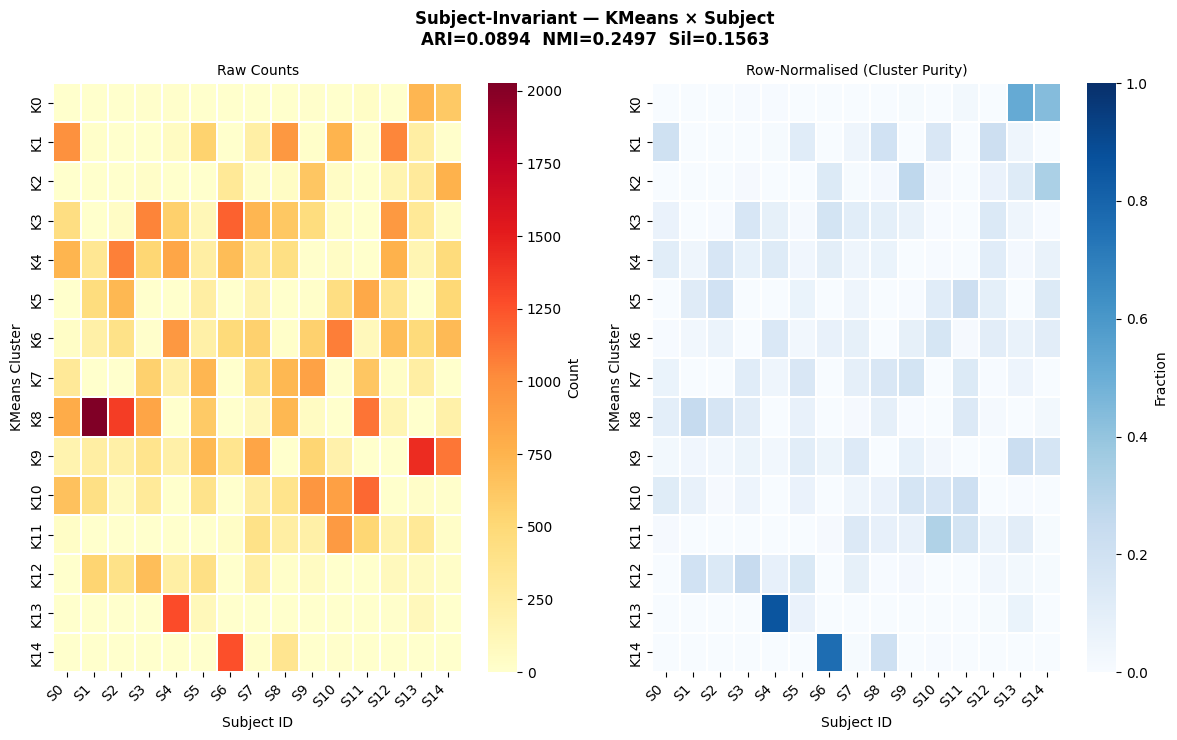

Saved → ./embedding_plots/Subject-Invariant_heatmap.png


In [35]:
for rd in run_data:
    S, K = rd["S"], rd["K"]
    unique_s = np.unique(S)
    unique_k = np.unique(K)

    # Build confusion matrix: rows=cluster, cols=subject
    mat = np.zeros((len(unique_k), len(unique_s)), dtype=int)
    for ki, k in enumerate(unique_k):
        for si, s in enumerate(unique_s):
            mat[ki, si] = np.sum((K == k) & (S == s))

    # Normalise by cluster size (row-wise) so colour = purity
    mat_norm = mat / mat.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(max(10, len(unique_s) * 0.8),
                                             max(7,  len(unique_k) * 0.5)))
    fig.suptitle(f"{rd['label']} — KMeans × Subject\n"
                 f"ARI={rd['metrics']['ARI']}  "
                 f"NMI={rd['metrics']['NMI']}  "
                 f"Sil={rd['metrics']['Silhouette']}",
                 fontsize=12, fontweight="bold")

    xlabels = [f"S{s}" for s in unique_s]
    ylabels = [f"K{k}" for k in unique_k]

    # Raw counts
    sns.heatmap(mat, ax=axes[0], cmap="YlOrRd",
                xticklabels=xlabels, yticklabels=ylabels,
                annot=(mat.shape[0] * mat.shape[1] <= 200),
                fmt="d", linewidths=0.3, cbar_kws={"label": "Count"})
    axes[0].set_xlabel("Subject ID"); axes[0].set_ylabel("KMeans Cluster")
    axes[0].set_title("Raw Counts", fontsize=10)
    axes[0].set_xticklabels(xlabels, rotation=45, ha="right")

    # Row-normalised (cluster purity per subject)
    sns.heatmap(mat_norm, ax=axes[1], cmap="Blues", vmin=0, vmax=1,
                xticklabels=xlabels, yticklabels=ylabels,
                annot=(mat.shape[0] * mat.shape[1] <= 200),
                fmt=".2f", linewidths=0.3, cbar_kws={"label": "Fraction"})
    axes[1].set_xlabel("Subject ID"); axes[1].set_ylabel("KMeans Cluster")
    axes[1].set_title("Row-Normalised (Cluster Purity)", fontsize=10)
    axes[1].set_xticklabels(xlabels, rotation=45, ha="right")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR,
                             f"{rd['label'].replace(' ', '_')}_heatmap.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

## 8. Multi-Run Comparison (if more than one run)

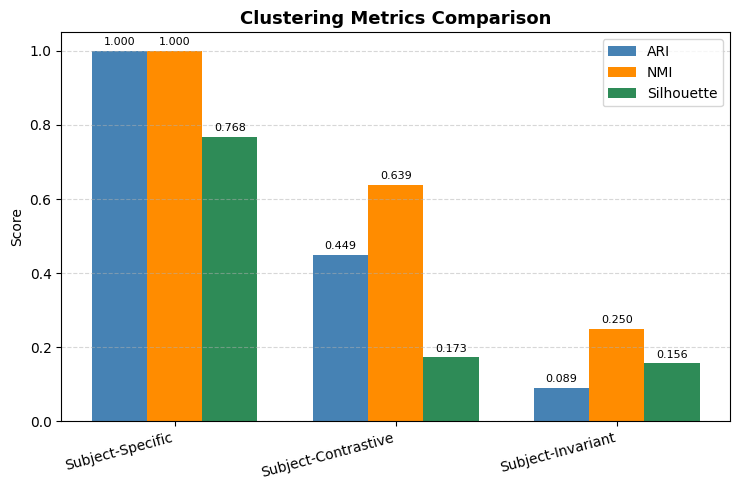

Saved → ./embedding_plots/metrics_comparison.png

── Metrics Summary ──
Model                               ARI      NMI   Silhouette
--------------------------------------------------------------
Subject-Specific                 1.0000   1.0000       0.7680
Subject-Contrastive              0.4494   0.6387       0.1730
Subject-Invariant                0.0894   0.2497       0.1563


In [36]:
if len(run_data) > 1:
    labels  = [rd["label"]              for rd in run_data]
    ari_vals = [rd["metrics"]["ARI"]     for rd in run_data]
    nmi_vals = [rd["metrics"]["NMI"]     for rd in run_data]
    sil_vals = [rd["metrics"]["Silhouette"] for rd in run_data]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(7, len(labels) * 2.5), 5))
    bars1 = ax.bar(x - width, ari_vals, width, label="ARI",       color="steelblue")
    bars2 = ax.bar(x,         nmi_vals, width, label="NMI",       color="darkorange")
    bars3 = ax.bar(x + width, sil_vals, width, label="Silhouette",color="seagreen")

    for bars in (bars1, bars2, bars3):
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Clustering Metrics Comparison",
                 fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "metrics_comparison.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

    # Also print a summary table
    print("\n── Metrics Summary ──")
    print(f"{'Model':<30} {'ARI':>8} {'NMI':>8} {'Silhouette':>12}")
    print("-" * 62)
    for rd in run_data:
        m = rd["metrics"]
        print(f"{rd['label']:<30} {m['ARI']:>8.4f} {m['NMI']:>8.4f} {m['Silhouette']:>12.4f}")
else:
    print("Only one run — add more entries to RUNS for comparison.")
    m = run_data[0]["metrics"]
    print(f"\nMetrics for '{run_data[0]['label']}':")
    for k, v in m.items():
        print(f"  {k}: {v}")

## 9. Save Metrics to JSON

In [ ]:
summary = []
for rd in run_data:
    summary.append({
        "model":      rd["label"],
        "n_samples":  int(len(rd["E"])),
        "n_subjects": int(len(np.unique(rd["S"]))),
        "n_clusters": int(rd["k"]),
        **rd["metrics"],
    })

metrics_path = os.path.join(OUTPUT_DIR, "clustering_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Metrics saved → {metrics_path}")
print(json.dumps(summary, indent=2))